# Data Quality Check and EDA

Цель:
- загрузить и проверить датасет churn;
- оценить качество данных;
- изучить целевую переменную `Churn`;
- зафиксировать первые наблюдения перед baseline-моделью.


In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")


## Data Loading

Определяем путь к датасету и загружаем CSV в `DataFrame`.


In [30]:
from pathlib import Path

possible_paths = [
    Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("CSV file not found in data/ folder")


df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")


Dataset loaded from: ..\data\WA_Fn-UseC_-Telco-Customer-Churn.csv


## First Look

На этом этапе смотрим:
- размер датасета;
- первые строки таблицы;
- список колонок;
- базовую статистику по числовым признакам.

Это помогает быстро понять структуру данных перед более детальной проверкой качества.


In [33]:
df.shape

(7043, 21)

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.columns.tolist()


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [36]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Target Audit

Проверяем целевую переменную `Churn`:
- присутствует ли она в датасете;
- какие значения принимает;
- как распределены классы.

Это важно, чтобы убедиться, что задача действительно является бинарной классификацией.


In [37]:
"Churn" in df.columns


True

In [38]:
df["Churn"].unique()


array(['No', 'Yes'], dtype=object)

In [39]:
df["Churn"].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Data Schema

Проверяем типы данных и общую структуру таблицы.

На этом этапе важно заметить:
- какие признаки числовые;
- какие признаков хранятся как строки;
- нет ли подозрительных колонок, которые требуют дополнительной очистки.


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Missing Values and Duplicates

Проверяем:
- есть ли пропуски;
- есть ли полностью повторяющиеся строки;
- есть ли признаки, которые требуют отдельной проверки качества данных.


In [43]:
df.isna().sum().sort_values(ascending=False)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [44]:
df.duplicated().sum()


np.int64(0)

In [45]:
df["customerID"].nunique(), df.shape[0]


(7043, 7043)

## Data Quality Check for `TotalCharges`

Колонка `TotalCharges` требует отдельной проверки, потому что в этом датасете она часто хранится как текст и может содержать пустые строки.




In [46]:
(df["TotalCharges"] == " ").sum()


np.int64(11)

In [47]:
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [48]:
df["TotalCharges_num"].isna().sum()


np.int64(11)

In [49]:
df[["TotalCharges", "TotalCharges_num"]].head()


,TotalCharges,TotalCharges_num
0,29.85,29.85
1,1889.5,1889.50
2,108.15,108.15
3,1840.75,1840.75
4,151.65,151.65


## Target Preparation

Создаем бинарную версию target, чтобы упростить последующий анализ, визуализации и расчет доли churn.


In [50]:
df["Churn_binary"] = df["Churn"].map({"No": 0, "Yes": 1})


In [51]:
df[["Churn", "Churn_binary"]].head()


,Churn,Churn_binary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [52]:
churn_rate = df["Churn_binary"].mean()
churn_rate


np.float64(0.2653698707936959)

## Preliminary Findings

1. Датасет содержит 7043 наблюдения и 21 колонку, что достаточно для построения baseline-модели churn prediction.
2. Целевая переменная `Churn` является бинарной (`Yes` / `No`) и подходит для задачи классификации.
3. Класс churn составляет около 26.5%, поэтому при оценке модели важно учитывать дисбаланс классов и не ограничиваться метрикой `accuracy`.
4. В датасете нет явных `NaN`, но колонка `TotalCharges` содержит 11 пустых строк и требует дополнительной обработки.
5. Полных дубликатов строк не обнаружено.
6. `customerID` является уникальным идентификатором клиента и, вероятно, не должен использоваться как признак модели.


## EDA: Tenure

Начинаем с признака `tenure` — количества месяцев, которые клиент находится в компании.

Это один из самых важных признаков в churn-задачах, потому что новые и старые клиенты часто ведут себя по-разному.


In [54]:
df["tenure"].describe()


count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

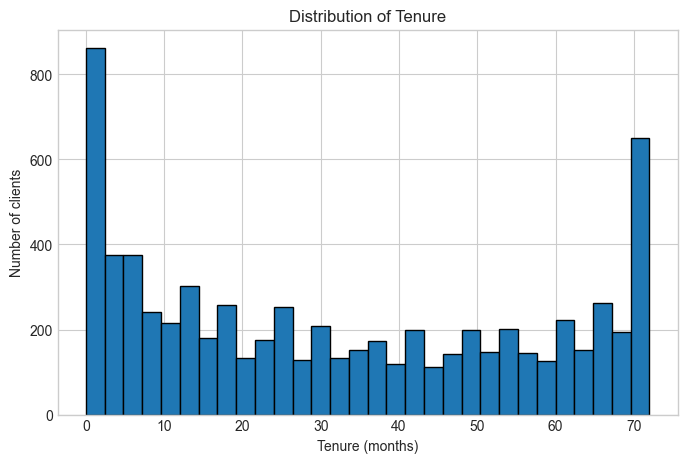

In [55]:
plt.figure(figsize=(8, 5))
plt.hist(df["tenure"], bins=30, edgecolor="black")
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of clients")
plt.show()


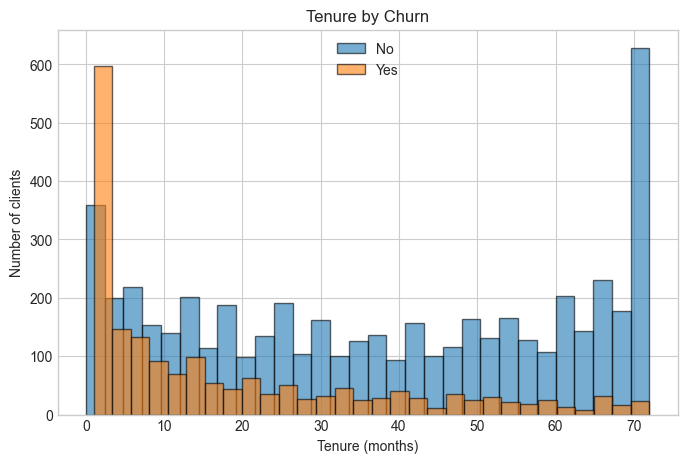

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["Churn"] == "No"]["tenure"], bins=30, alpha=0.6, label="No", edgecolor="black")
plt.hist(df[df["Churn"] == "Yes"]["tenure"], bins=30, alpha=0.6, label="Yes", edgecolor="black")
plt.title("Tenure by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of clients")
plt.legend()
plt.show()


### Observation: Tenure

Признак `tenure` выглядит информативным для задачи churn prediction.

По описательной статистике:
- медианный стаж клиента составляет 29 месяцев;
- 25% клиентов имеют tenure не больше 9 месяцев;
- 75% клиентов имеют tenure не больше 55 месяцев;
- диапазон значений широкий: от 0 до 72 месяцев.

По распределению видно, что датасет содержит много как очень новых клиентов, так и клиентов с максимальным стажем, что делает признак потенциально полезным для сегментации.

Сравнение churn и non-churn показывает, что отток чаще встречается среди клиентов с небольшим tenure. Для клиентов с большим стажем доля churn заметно ниже. Это позволяет предположить, что новые клиенты менее устойчивы и чаще уходят, тогда как долгосрочные клиенты более лояльны.


## EDA: Monthly Charges

Теперь посмотрим на `MonthlyCharges` — ежемесячные платежи клиента.

Этот признак полезен, потому что уровень ежемесячных расходов может быть связан с вероятностью оттока.


In [57]:
df["MonthlyCharges"].describe()


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

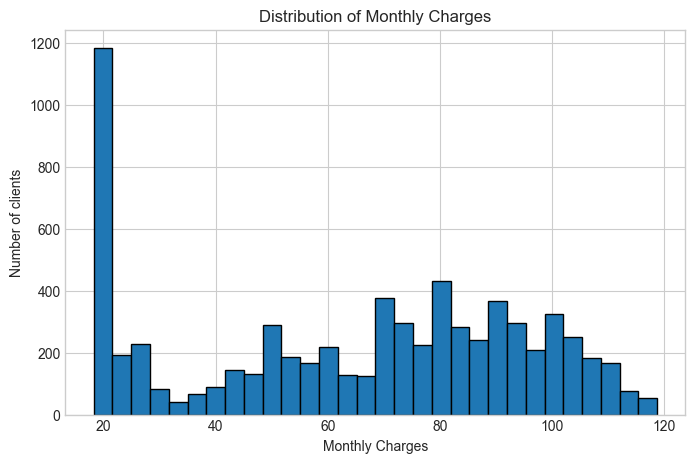

In [58]:
plt.figure(figsize=(8, 5))
plt.hist(df["MonthlyCharges"], bins=30, edgecolor="black")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of clients")
plt.show()


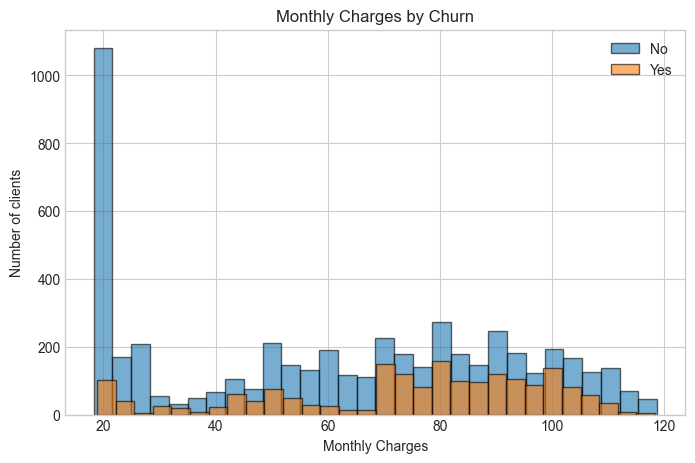

In [59]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["Churn"] == "No"]["MonthlyCharges"], bins=30, alpha=0.6, label="No", edgecolor="black")
plt.hist(df[df["Churn"] == "Yes"]["MonthlyCharges"], bins=30, alpha=0.6, label="Yes", edgecolor="black")
plt.title("Monthly Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of clients")
plt.legend()
plt.show()


### Observation: Monthly Charges

Признак `MonthlyCharges` потенциально может быть связан с churn, но на текущем этапе вывод нужно формулировать осторожно.

По описательной статистике видно, что ежемесячные платежи имеют широкий диапазон значений — от 18.25 до 118.75, а медиана составляет 70.35. Это говорит о наличии нескольких ценовых сегментов среди клиентов.

По графикам видно, что распределение `MonthlyCharges` неоднородно: в датасете присутствует выраженная группа клиентов с низкими ежемесячными платежами, а также широкое распределение значений в среднем и высоком диапазоне.

На наложенной гистограмме заметно, что клиенты с churn представлены в разных ценовых диапазонах, однако из-за различия в размере классов делать сильный вывод о характере связи пока рано. Для более надежной интерпретации стоит дополнительно сравнить churn rate по диапазонам `MonthlyCharges` или посмотреть нормированные распределения.


## Monthly Charges and Churn Rate

Чтобы точнее оценить связь между `MonthlyCharges` и churn, посмотрим, как меняется доля churn по диапазонам ежемесячных платежей.


In [60]:
df["MonthlyCharges_bin"] = pd.qcut(df["MonthlyCharges"], q=5)

monthly_churn = df.groupby("MonthlyCharges_bin")["Churn_binary"].mean()

monthly_churn


C:\Users\slvtm\AppData\Local\Temp\ipykernel_13452\3937096773.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_churn = df.groupby("MonthlyCharges_bin")["Churn_binary"].mean()


MonthlyCharges_bin
(18.249, 25.05]    0.091549
(25.05, 58.83]     0.249821
(58.83, 79.1]      0.297661
(79.1, 94.25]      0.361052
(94.25, 118.75]    0.328125
Name: Churn_binary, dtype: float64

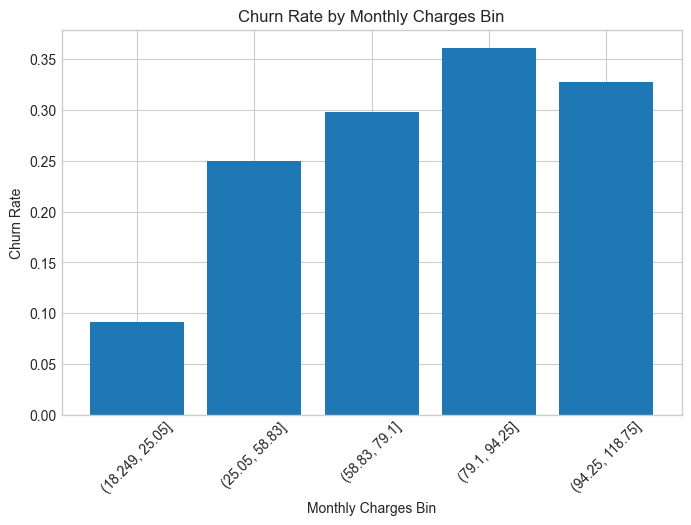

In [61]:
plt.figure(figsize=(8, 5))
plt.bar(monthly_churn.index.astype(str), monthly_churn.values)
plt.title("Churn Rate by Monthly Charges Bin")
plt.xlabel("Monthly Charges Bin")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()


### Observation: Monthly Charges

Дополнительный анализ показывает, что `MonthlyCharges` действительно связан с churn rate.

При разбиении признака на квантильные интервалы видно, что в сегменте с самыми низкими ежемесячными платежами churn rate составляет около 9%, тогда как в более дорогих сегментах он заметно выше и достигает примерно 36%.

Зависимость не является строго монотонной на всем диапазоне, поскольку в самом верхнем ценовом сегменте наблюдается небольшое снижение относительно пикового значения. Тем не менее общий паттерн сохраняется: более высокие ежемесячные платежи в целом связаны с большей вероятностью оттока.

Это позволяет рассматривать `MonthlyCharges` как важный кандидат в baseline-модель.


## EDA: Contract Type

Признак `Contract` является категориальным и, как правило, очень важен для churn prediction.

Тип контракта напрямую связан с устойчивостью клиента и может сильно влиять на вероятность оттока.


In [62]:
df["Contract"].value_counts()


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [63]:
df.groupby("Contract")["Churn_binary"].mean().sort_values(ascending=False)


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_binary, dtype: float64

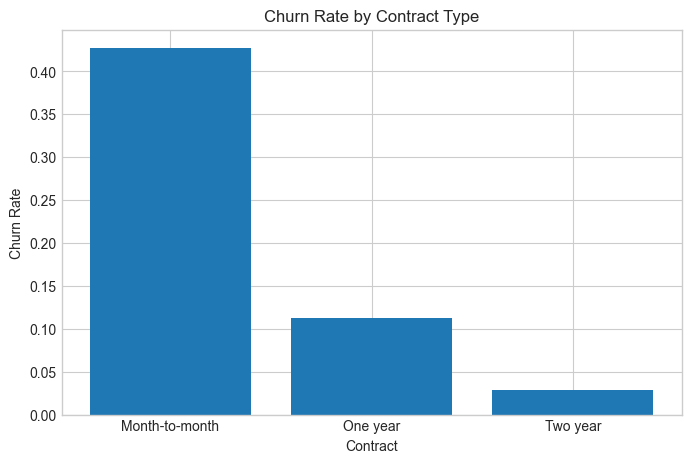

In [64]:
contract_churn = df.groupby("Contract")["Churn_binary"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(contract_churn.index, contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.show()


### Observation: Contract

Признак `Contract` является одним из самых информативных для задачи churn prediction.

В датасете преобладают клиенты с контрактом `Month-to-month` (3875 наблюдений), тогда как `One year` и `Two year` встречаются реже. При этом churn rate существенно различается между типами контрактов:
- `Month-to-month` — около 42.7%
- `One year` — около 11.3%
- `Two year` — около 2.8%

График и агрегированные значения показывают очень выраженную связь между типом контракта и вероятностью оттока. Клиенты с помесячным контрактом уходят значительно чаще, тогда как более долгосрочные контракты ассоциированы с гораздо более низким churn rate.

Это позволяет рассматривать `Contract` как один из ключевых признаков для baseline-модели и как важный фактор для бизнес-интерпретации оттока.


## EDA: Total Charges

После приведения `TotalCharges` к числовому виду можно посмотреть на распределение этого признака.

Пока не используем его для финальных выводов без оговорок, потому что ранее обнаружили проблемы качества данных.


In [65]:
df["TotalCharges_num"].describe()


count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges_num, dtype: float64

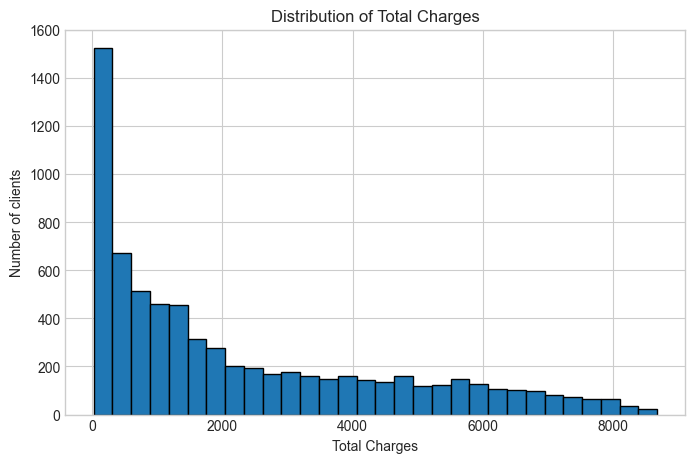

In [66]:
plt.figure(figsize=(8, 5))
plt.hist(df["TotalCharges_num"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of clients")
plt.show()


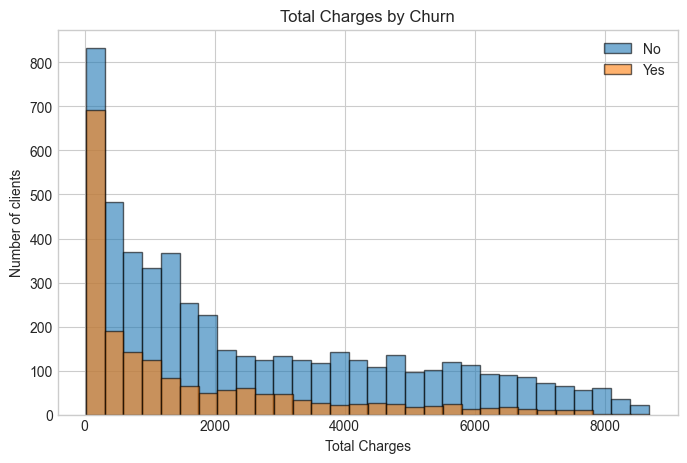

In [67]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["Churn"] == "No"]["TotalCharges_num"].dropna(), bins=30, alpha=0.6, label="No", edgecolor="black")
plt.hist(df[df["Churn"] == "Yes"]["TotalCharges_num"].dropna(), bins=30, alpha=0.6, label="Yes", edgecolor="black")
plt.title("Total Charges by Churn")
plt.xlabel("Total Charges")
plt.ylabel("Number of clients")
plt.legend()
plt.show()


### Observation: Total Charges

Признак `TotalCharges_num` выглядит потенциально информативным, но интерпретировать его нужно осторожно.

По общему распределению видно, что `TotalCharges_num` имеет выраженную правостороннюю асимметрию: большая часть клиентов сосредоточена в области низких суммарных платежей, а по мере роста значения частота наблюдений снижается. Это ожидаемо для накопительного признака, который зависит от длительности пользования услугой.

На наложенной гистограмме видно, что клиенты с churn чаще представлены в области низких `TotalCharges_num`, тогда как среди клиентов без churn больше наблюдений в среднем и высоком диапазоне. Это может говорить о том, что клиенты с небольшими накопленными платежами уходят чаще, а клиенты с большими суммарными платежами, как правило, остаются дольше.

Однако этот вывод нужно делать с оговоркой: `TotalCharges_num` тесно связан с `tenure`, поэтому часть наблюдаемого эффекта, вероятно, объясняется именно стажем клиента, а не только суммой платежей как самостоятельным фактором. Кроме того, ранее в колонке были обнаружены пустые значения, поэтому перед использованием в модели признак требует аккуратной подготовки.


## Correlation Heatmap for Numeric Features

Дополнительно посмотрим на корреляции между числовыми признаками.

Этот шаг помогает:
- понять, какие числовые признаки сильнее связаны друг с другом;
- проверить, насколько `TotalCharges_num` связан с `tenure`;
- увидеть, есть ли заметная линейная связь между числовыми признаками и `Churn_binary`.

Важно: корреляционная heatmap полезна только для числовых признаков и не отражает влияние категориальных переменных, таких как `Contract`.


In [75]:
numeric_corr = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_num", "Churn_binary"]].corr()

numeric_corr


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_num,Churn_binary
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,0.193356
TotalCharges_num,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn_binary,0.150889,-0.352229,0.193356,-0.199484,1.000000


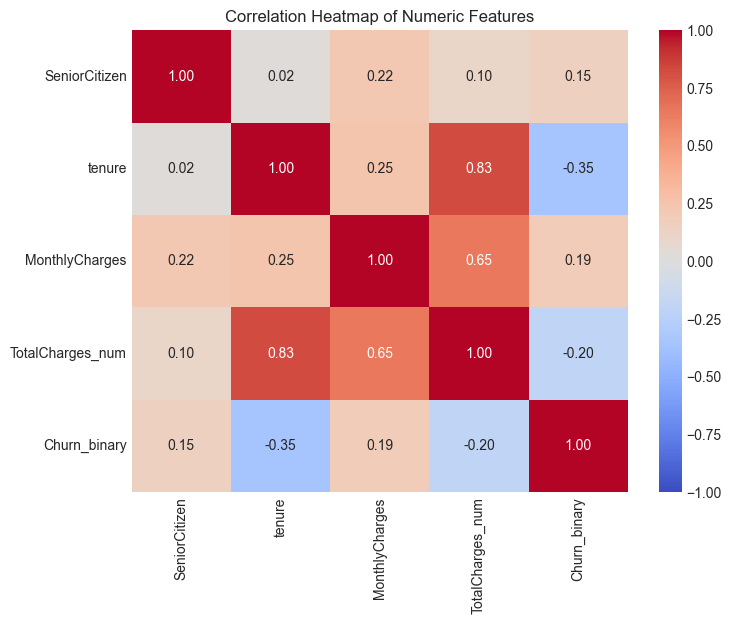

In [79]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


### Observation: Correlation Heatmap

Корреляционная heatmap показывает, что самым сильным линейным отношением среди числовых признаков является связь между `tenure` и `TotalCharges_num` (`0.83`). Это ожидаемо, поскольку `TotalCharges` является накопительным признаком и напрямую связан с длительностью пользования услугами.

Связь `tenure` с `Churn_binary` является умеренно отрицательной (`-0.35`), что согласуется с предыдущими наблюдениями: клиенты с большим стажем реже уходят. `MonthlyCharges` имеет слабую положительную связь с `Churn_binary` (`0.19`), что также соответствует предыдущему анализу, но не указывает на очень сильную линейную зависимость.




## EDA Summary

По результатам первичного анализа можно сделать следующие выводы:

1. Датасет содержит 7043 наблюдения и 21 колонку, что достаточно для построения baseline-модели churn prediction.
2. Целевая переменная `Churn` является бинарной (`Yes` / `No`) и подходит для задачи классификации.
3. Класс churn составляет около 26.5%, поэтому одной `accuracy` для оценки модели будет недостаточно.
4. Признак `tenure` выглядит информативным: клиенты с небольшим стажем чаще уходят, а среди клиентов с высоким tenure churn ниже.
5. `MonthlyCharges` связан с churn: в более дорогих сегментах churn rate в целом выше, чем в сегменте с самыми низкими ежемесячными платежами.
6. `Contract` является одним из самых сильных и интерпретируемых признаков: churn rate для `Month-to-month` существенно выше, чем для `One year` и `Two year`.
7. В колонке `TotalCharges` нет явных `NaN`, но есть 11 пустых строк, из-за чего признак пришлось отдельно привести к числовому виду.
8. `TotalCharges_num` потенциально полезен, но тесно связан с `tenure`, поэтому требует аккуратной интерпретации и корректной обработки перед использованием в модели.
9. `customerID` является уникальным идентификатором клиента и не должен использоваться как признак модели.

Следующий шаг — подготовить данные и построить baseline-модель.
